In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from PIL import Image
import sys
sys.path.append('../../../')

In [5]:
def compute_distance_map(instance_segmentation_map):
    """
    Computes the Euclidean Distance Transform (EDT) where boundaries have zero distance.
    
    Args:
        instance_segmentation_map (numpy.ndarray): Instance segmentation map where each object has a unique label.

    Returns:
        distance_map (numpy.ndarray): Distance map where each pixel represents the distance to the nearest boundary.
    """
    # Convert instance segmentation map to binary mask (foreground = 1, background = 0)
    binary_mask = (instance_segmentation_map > 0).astype(np.uint8)

    # Compute boundaries using morphological gradient
    padded = np.pad(binary_mask, pad_width=1, mode='constant', constant_values=0)
    eroded = padded[1:-1, 1:-1] & padded[:-2, 1:-1] & padded[2:, 1:-1] & \
             padded[1:-1, :-2] & padded[1:-1, 2:]  # Manual erosion

    boundary_mask = binary_mask - eroded  # Extracts boundaries

    # Set boundary pixels to 0 for distance transform
    binary_mask[boundary_mask > 0] = 0

    # Compute distance transform (distance from every pixel to the nearest boundary)
    distance_map = distance_transform_edt(binary_mask)

    return distance_map, boundary_mask

# Load an instance segmentation map from PNG using PIL
instance_map = Image.open("/home/sheida.rahnamai/EGFP/annotations/MFGTMPcx7_170607100001_K23f08d1_RA.png").convert("L")  # Convert to grayscale
instance_map = np.array(instance_map)  # Convert to NumPy array

# Compute the distance map
distance_map, boundary_mask = compute_distance_map(instance_map)

# Normalize for visualization
normalized_distance_map = distance_map / np.max(distance_map)

# Save distance map (if needed)
Image.fromarray((normalized_distance_map * 255).astype(np.uint8)).save("distance_map.png")

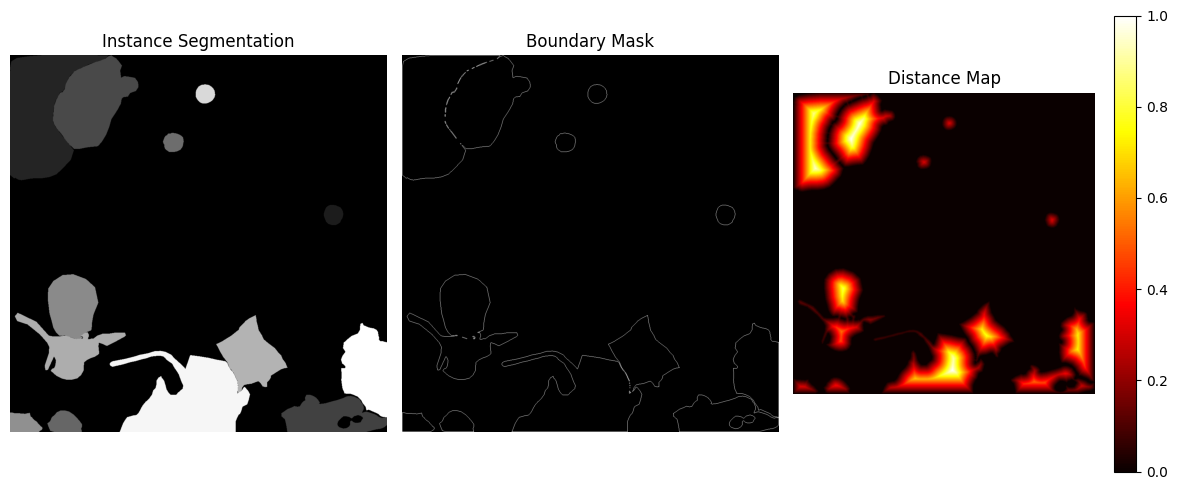

In [6]:
# Plot the results
plt.figure(figsize=(12, 5))

# Original Instance Segmentation Map
plt.subplot(1, 3, 1)
plt.imshow(instance_map, cmap="gray")
plt.title("Instance Segmentation")
plt.axis("off")

# Boundary Map
plt.subplot(1, 3, 2)
plt.imshow(boundary_mask, cmap="gray")
plt.title("Boundary Mask")
plt.axis("off")

# Distance Map with Boundaries as Zero
plt.subplot(1, 3, 3)
plt.imshow(normalized_distance_map, cmap="hot")
plt.colorbar()
plt.title("Distance Map")
plt.axis("off")

plt.tight_layout()
plt.show()
